<a href="https://colab.research.google.com/github/2403A52058/NLP_LABASSIGNMENTS/blob/main/NLP_LAB_(09).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

# Numerical operations
import numpy as np

# Gensim is used to load and work with pre-trained word embeddings
import gensim.downloader as api

# For similarity computation
from numpy.linalg import norm

# Visualization libraries (optional)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.1 MB/s eta 0:00:00


In [ ]:
# Load pre-trained Word2Vec model (Google News vectors – smaller version)
print("Loading Word2Vec model...")
model = api.load("word2vec-google-news-300")

print("Model loaded successfully!")
print("Vocabulary size:", len(model))


Loading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded successfully!
Vocabulary size: 3000000


In [ ]:
# Display vector for a sample word
word = "king"
vector = model[word]

print(f"Word vector for '{word}':")
print(vector)
print("Vector length:", len(vector))


Word vector for 'king':
[ 1.25976562e-01  2.97851562e-02  8.60595703e-03  1.39648438e-01
 -2.56347656e-02 -3.61328125e-02  1.11816406e-01 -1.98242188e-01
  5.12695312e-02  3.63281250e-01 -2.42187500e-01 -3.02734375e-01
 -1.77734375e-01 -2.49023438e-02 -1.67968750e-01 -1.69921875e-01
  3.46679688e-02  5.21850586e-03  4.63867188e-02  1.28906250e-01
  1.36718750e-01  1.12792969e-01  5.95703125e-02  1.36718750e-01
  1.01074219e-01 -1.76757812e-01 -2.51953125e-01  5.98144531e-02
  3.41796875e-01 -3.11279297e-02  1.04492188e-01  6.17675781e-02
  1.24511719e-01  4.00390625e-01 -3.22265625e-01  8.39843750e-02
  3.90625000e-02  5.85937500e-03  7.03125000e-02  1.72851562e-01
  1.38671875e-01 -2.31445312e-01  2.83203125e-01  1.42578125e-01
  3.41796875e-01 -2.39257812e-02 -1.09863281e-01  3.32031250e-02
 -5.46875000e-02  1.53198242e-02 -1.62109375e-01  1.58203125e-01
 -2.59765625e-01  2.01416016e-02 -1.63085938e-01  1.35803223e-03
 -1.44531250e-01 -5.68847656e-02  4.29687500e-02 -2.46582031e-02
 

In [ ]:
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))


In [ ]:
word_pairs = [
    ("doctor", "nurse"),
    ("cat", "dog"),
    ("car", "bus"),
    ("king", "queen"),
    ("apple", "banana"),
    ("teacher", "student"),
    ("man", "woman"),
    ("city", "village"),
    ("computer", "laptop"),
    ("india", "china")
]

print("Word Similarity Scores:\n")
for w1, w2 in word_pairs:
    sim = cosine_similarity(model[w1], model[w2])
    print(f"{w1:10} - {w2:10} : {sim:.3f}")


Word Similarity Scores:

doctor     - nurse      : 0.632
cat        - dog        : 0.761
car        - bus        : 0.469
king       - queen      : 0.651
apple      - banana     : 0.532
teacher    - student    : 0.630
man        - woman      : 0.766
city       - village    : 0.479
computer   - laptop     : 0.664
india      - china      : 0.353


In [ ]:
words = ["king", "university", "computer", "doctor", "india"]

for word in words:
    print(f"\nTop 5 words similar to '{word}':")
    for similar_word, score in model.most_similar(word, topn=5):
        print(f"{similar_word:15} : {score:.3f}")



Top 5 words similar to 'king':
kings           : 0.714
queen           : 0.651
monarch         : 0.641
crown_prince    : 0.620
prince          : 0.616

Top 5 words similar to 'university':
universities    : 0.700
faculty         : 0.678
unversity       : 0.676
undergraduate   : 0.659
univeristy      : 0.659

Top 5 words similar to 'computer':
computers       : 0.798
laptop          : 0.664
laptop_computer : 0.655
Computer        : 0.647
com_puter       : 0.608

Top 5 words similar to 'doctor':
physician       : 0.781
doctors         : 0.748
gynecologist    : 0.695
surgeon         : 0.679
dentist         : 0.679

Top 5 words similar to 'india':
indian          : 0.697
usa             : 0.684
pakistan        : 0.682
chennai         : 0.668
america         : 0.659


In [ ]:
analogies = [
    ("king", "man", "woman"),
    ("paris", "france", "india"),
    ("teacher", "school", "hospital")
]

for a, b, c in analogies:
    result = model.most_similar(positive=[c, a], negative=[b], topn=1)
    print(f"{a} - {b} + {c} = {result[0][0]}")


king - man + woman = queen
paris - france + india = chennai
teacher - school + hospital = Hospital


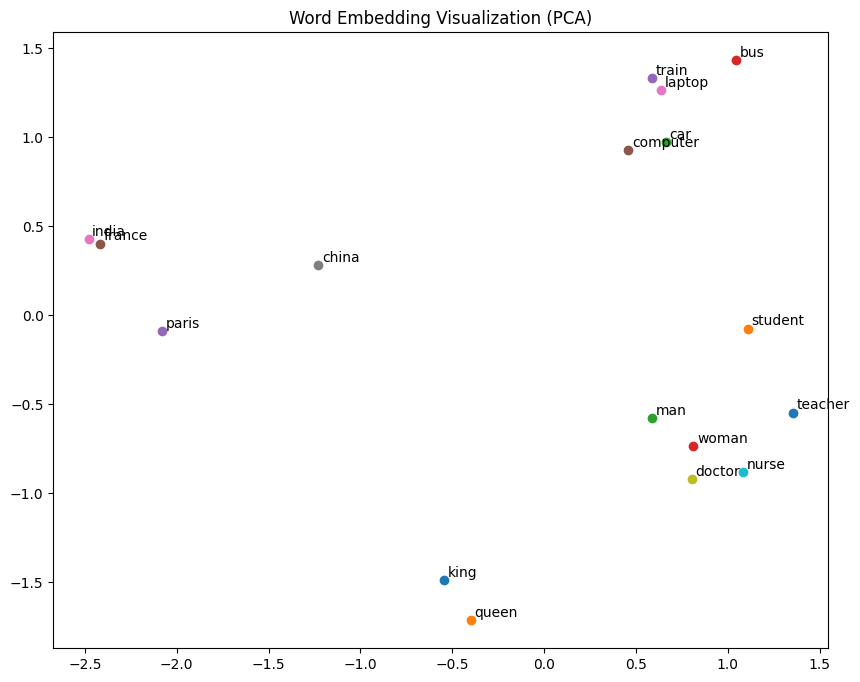

In [ ]:
words_to_plot = [
    "king","queen","man","woman",
    "paris","france","india","china",
    "doctor","nurse","teacher","student",
    "car","bus","train","computer","laptop"
]

vectors = np.array([model[word] for word in words_to_plot])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

plt.figure(figsize=(10,8))
for i, word in enumerate(words_to_plot):
    plt.scatter(reduced_vectors[i,0], reduced_vectors[i,1])
    plt.text(reduced_vectors[i,0]+0.02, reduced_vectors[i,1]+0.02, word)

plt.title("Word Embedding Visualization (PCA)")
plt.show()
